# **TABLE OF CONTENT**


1.   IMPORTING LIBRARIES & DATA CLEANING
2.   EDA
3.   DATA PREPROCESSING
4.   FEATURE ENGINEERING - Pending
5.   TRANNING MODEL
6.   EVALUATE



***1. IMPORTING LIBRARIES & DATA CLEANING***

In [ ]:
#Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.linear_model as lm

#Show all columns, without hiding any
pd.set_option('display.max_columns', None)

#Set the chart background to white with a grid for easier observation and comparison of data values.
sns.set(style="whitegrid")

In [ ]:
#Load the dataset
path = "/content/spotify_data clean.csv"
df = pd.read_csv(path)

#Quick look at the data
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",10/31/2025,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,10/31/2025,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,10/31/2025,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",10/31/2025,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,10/30/2025,2,single,2.39


In [ ]:
#Basic info about the dataset
df.info()

#Checking nulls
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

,0
track_id,0
track_name,0
track_number,0
track_popularity,0
explicit,0
artist_name,3
artist_popularity,0
artist_followers,0
artist_genres,3361
album_id,0


In [ ]:
# Convert release date to datetime
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')

# Extract useful date components
df['release_year'] = df['album_release_date'].dt.year
df['release_month'] = df['album_release_date'].dt.month

# Fill missing genres with 'Unknown'
df['artist_genres'] = df['artist_genres'].fillna('Unknown')

# Quick check
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year,release_month
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,2025,10
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07,2025,10
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,Unknown,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55,2025,10
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,2025,10
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39,2025,10


In [ ]:
# Check and remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicated_rows = initial_rows - df.shape[0]
print(f"Removed {duplicated_rows} duplicate rows.")
print(f"Remaining rows after removing duplicates: {df.shape[0]}")

Removed 0 duplicate rows.
Remaining rows after removing duplicates: 8582


In [ ]:
# Drop rows with missing values in target and key feature columns (`track_popularity`, `artist_popularity`)
initial_rows_after_duplicates = df.shape[0]
df.dropna(subset=['track_popularity', 'artist_popularity'], inplace=True)
dropped_for_prediction = initial_rows_after_duplicates - df.shape[0]
print(f"Dropped {dropped_for_prediction} rows due to missing values in 'track_popularity' or 'artist_popularity'.")

# For other remaining numerical columns with missing values, fill with the median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values for column '{col}' with median: {median_val}")

print("\nRe-check missing values after cleaning:")
print(df.isnull().sum())

Dropped 0 rows due to missing values in 'track_popularity' or 'artist_popularity'.

Re-check missing values after cleaning:
track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           3
artist_popularity     0
artist_followers      0
artist_genres         0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
release_year          0
release_month         0
dtype: int64


In [ ]:
# Convert release date to datetime
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')

# Extract useful date components
df['release_year'] = df['album_release_date'].dt.year
df['release_month'] = df['album_release_date'].dt.month

# Create a simple popularity category
df['popularity_level'] = pd.cut(df['track_popularity'],
                                bins=[-1, 30, 60, 100],
                                labels=['Low', 'Medium', 'High'])

# Fill missing genres with 'Unknown'
df['artist_genres'] = df['artist_genres'].fillna('Unknown')

# Quick check
display(df.head())

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year,release_month,popularity_level
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,2025,10,Low
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07,2025,10,Low
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,Unknown,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55,2025,10,Low
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,2025,10,Low
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39,2025,10,Low


***2. EDA***

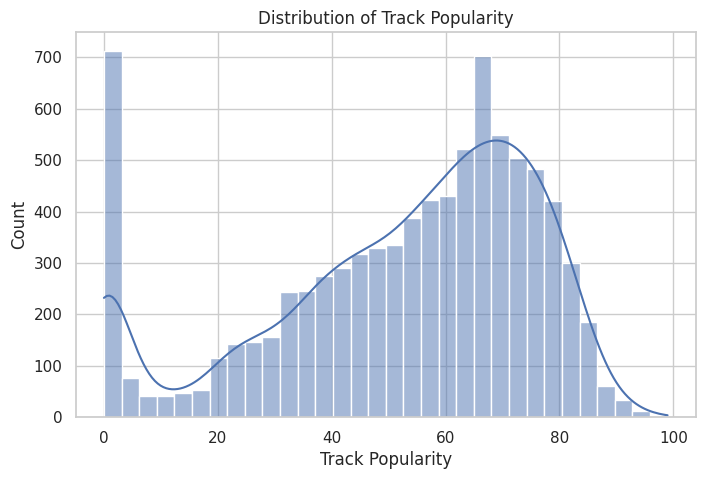

In [ ]:
import matplotlib.pyplot as plt
# Histogram popularity
plt.figure(figsize=(8,5))
sns.histplot(df['track_popularity'], kde=True)
plt.title("Distribution of Track Popularity")
plt.xlabel("Track Popularity")
plt.show()

The histogram of track popularity shows that most songs are concentrated in the medium-to-high popularity range, particularly between 50 and 80. A noticeable spike near zero indicates the presence of many low-popularity tracks. The distribution is not perfectly normal and exhibits slight skewness, suggesting that only a limited number of songs achieve extremely high popularity levels. This pattern reflects the common structure of streaming platforms, where a small proportion of tracks dominate audience attention.

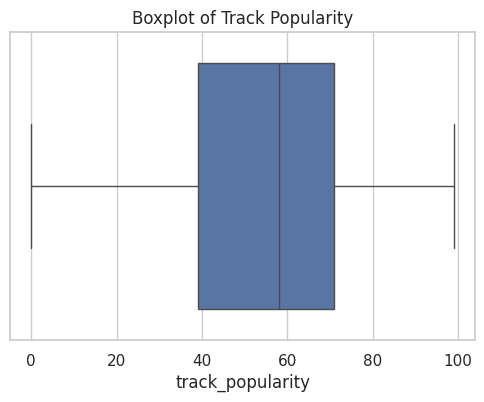

In [ ]:
# Boxplot popularity
plt.figure(figsize=(6,4))
sns.boxplot(x=df['track_popularity'])
plt.title("Boxplot of Track Popularity")
plt.show()

The boxplot of track popularity shows that the median popularity score is around 60, indicating that most songs in the dataset have moderate popularity levels. The interquartile range is concentrated between approximately 40 and 70, meaning that half of the tracks fall within this range. In addition, the whiskers extend from near 0 to almost 100, showing a wide spread of popularity values across the dataset. The absence of strong outliers suggests that the popularity data is relatively stable and not dominated by extreme values.

In [ ]:
# NUMERICAL FEATURES ANALYSIS

numerical_cols = [
    'track_number',
    'artist_popularity',
    'artist_followers',
    'album_total_tracks',
    'track_duration_min'
]

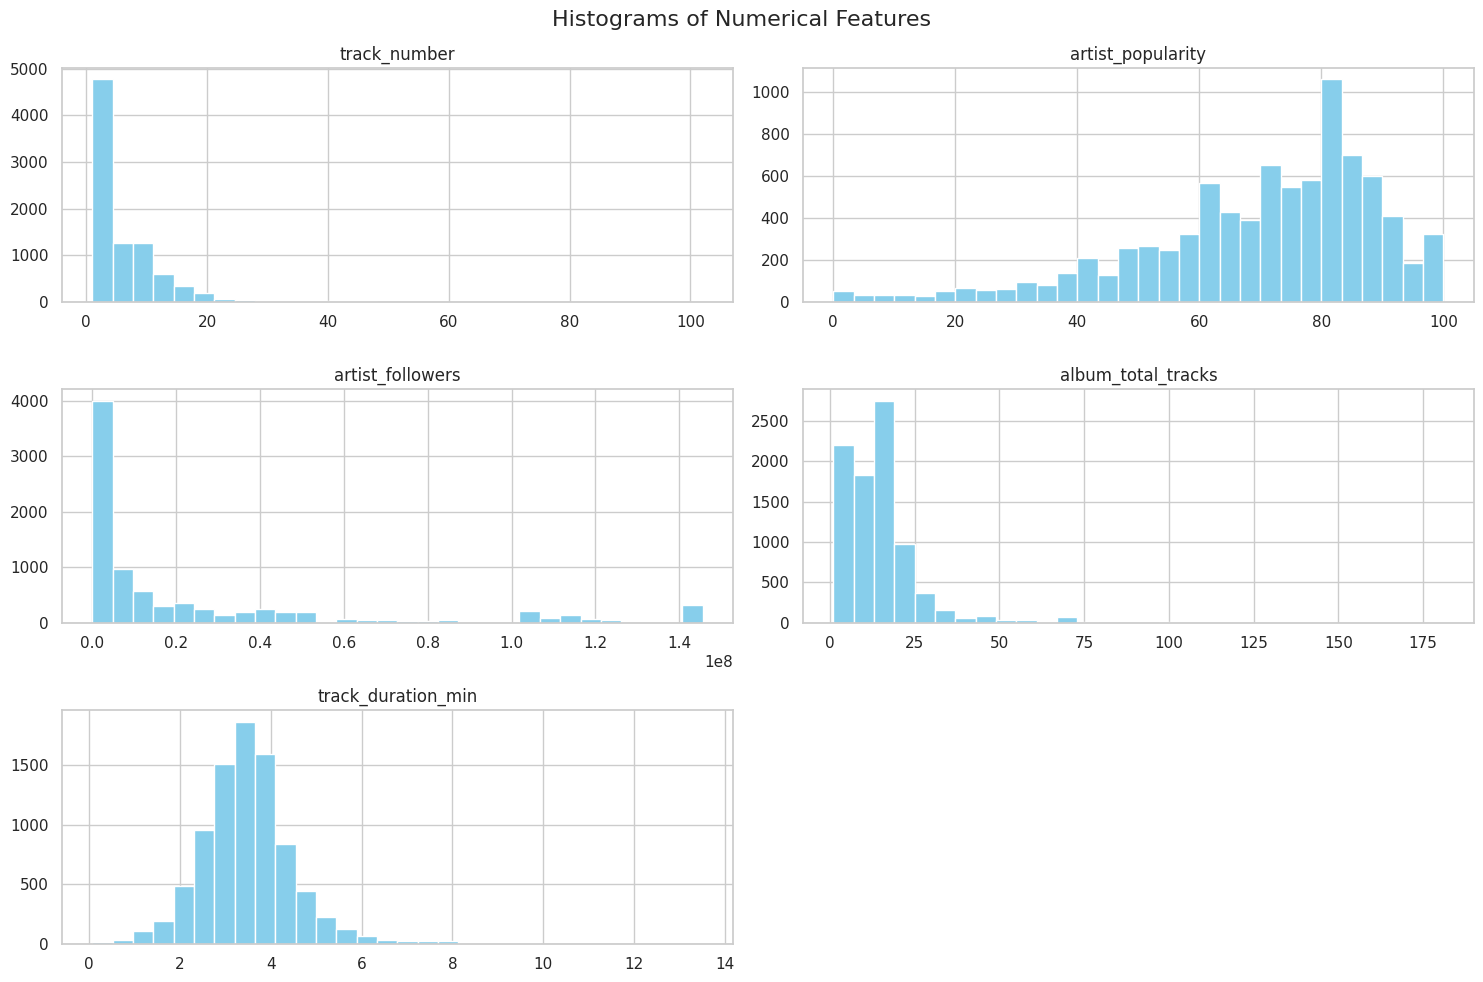

In [ ]:
# Histograms

df[numerical_cols].hist(
    figsize=(15,10),
    bins=30,
    color='skyblue'
)

plt.suptitle(
    "Histograms of Numerical Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

Most features, such as artist_followers and track_number, exhibit a strong right-skewed distribution, indicating that a small number of entries hold very high values while the majority are clustered at the lower end.

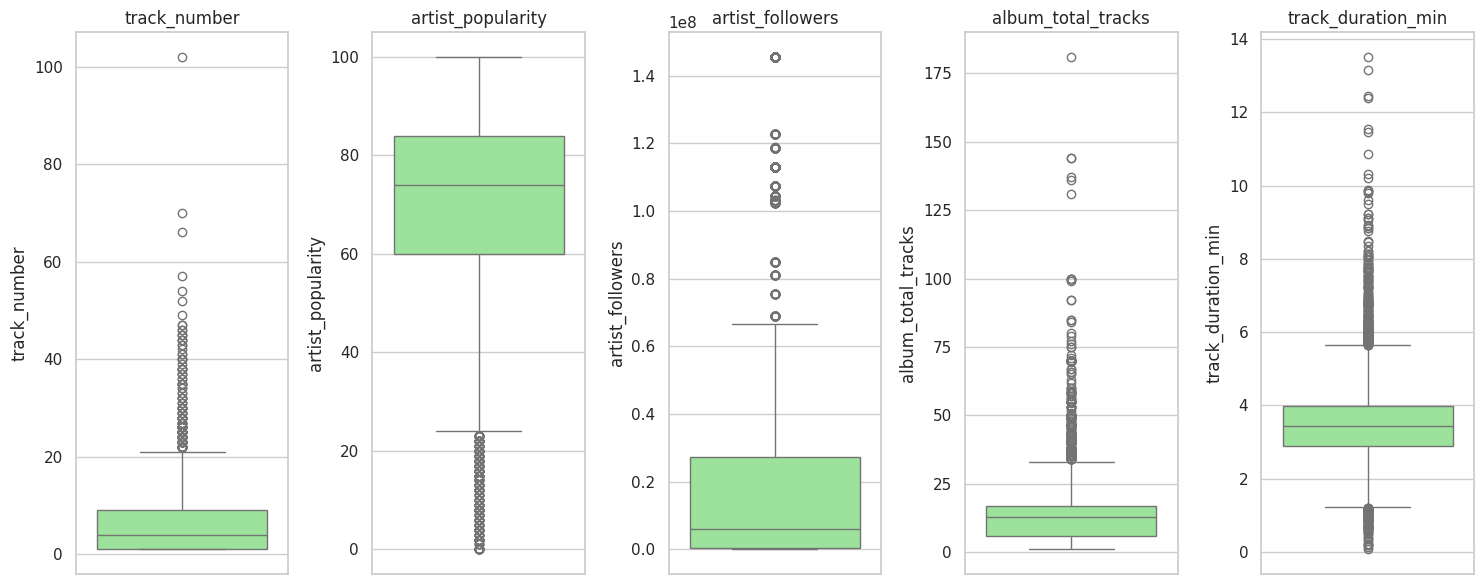

In [ ]:
# Boxplots

plt.figure(figsize=(15,6))

for i, col in enumerate(numerical_cols):

    plt.subplot(1, len(numerical_cols), i+1)

    sns.boxplot(
        y=df[col],
        color='lightgreen'
    )

    plt.title(col)

plt.tight_layout()

plt.show()

The dataset contains many right-skewed variables with significant outliers, especially artist_followers and album_total_tracks.

Most songs follow standard industry patterns in duration and album size, while a small number of superstar artists and extended albums create extreme values.

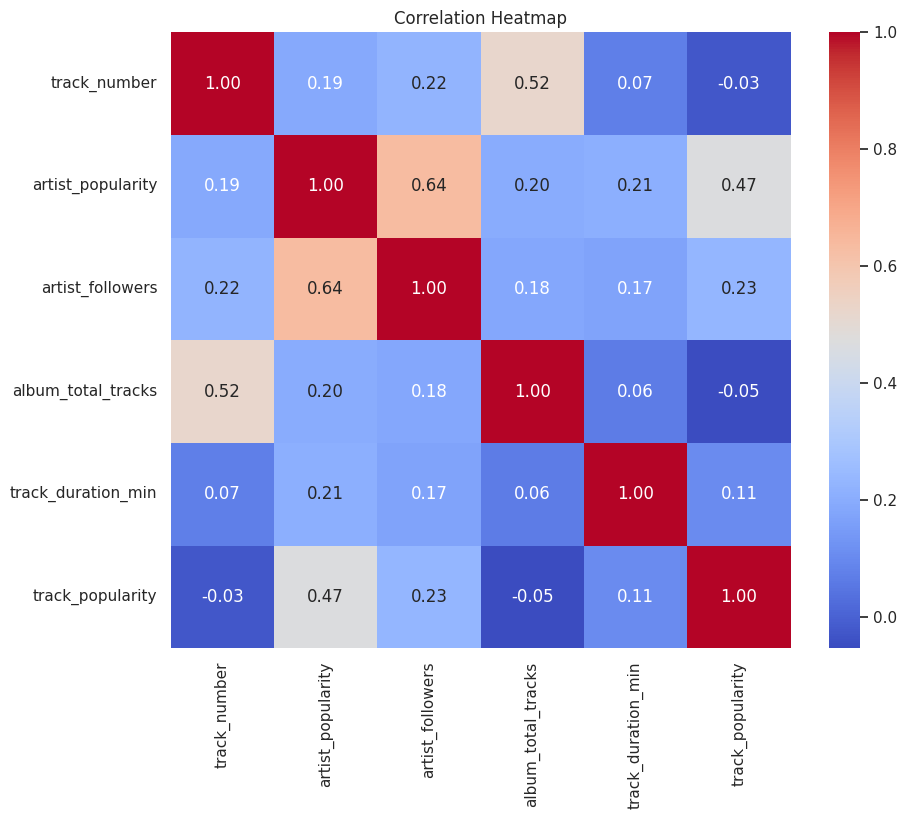

In [ ]:
# CORRELATION HEATMAP

corr_cols = numerical_cols + ['track_popularity']

corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

The heatmap highlights that artist_popularity is the most significant predictor of track_popularity with a moderate positive correlation of 0.47.

This indicates that a track's success is strongly tied to the artist's overall standing in the industry. Other features, such as track_duration_min and album_total_tracks, show negligible impact, suggesting that technical song characteristics matter less than artist brand power.

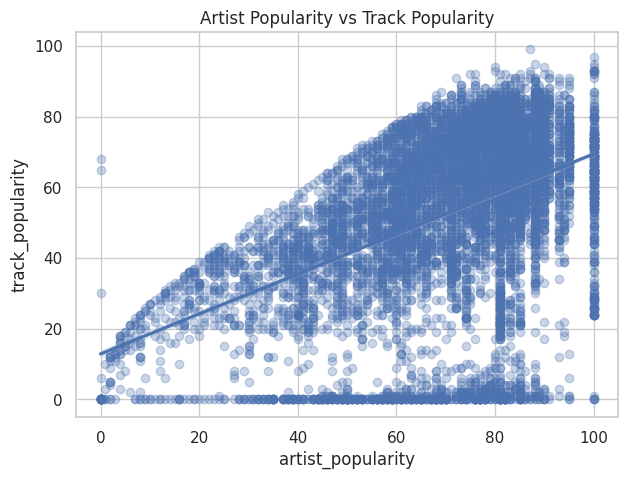

In [ ]:
# Artist Popularity vs Track Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='artist_popularity',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Artist Popularity vs Track Popularity")
plt.show()

This chart highlights the strong link between an artist's status and their track's performance.

The positive trend line proves that 'Track Popularity' is highly dependent on 'Artist Popularity,' making it the most impactful numerical feature in our dataset.

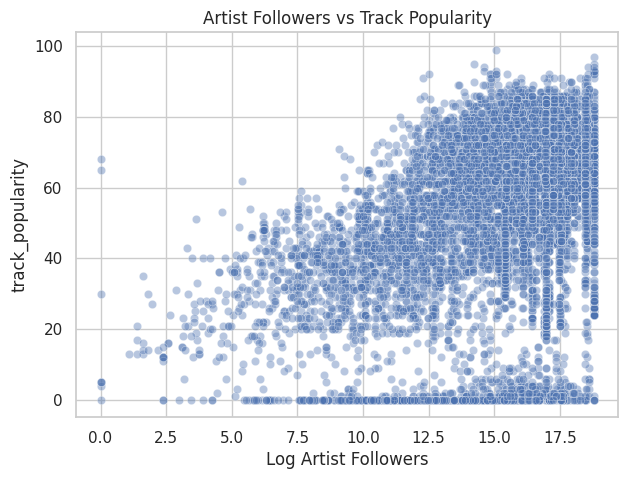

In [ ]:
# Artist Followers vs Track Popularity
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=np.log1p(df['artist_followers']),
    y=df['track_popularity'],
    alpha=0.4
)
plt.title("Artist Followers vs Track Popularity")
plt.xlabel("Log Artist Followers")
plt.show()

This scatter plot demonstrates a strong positive correlation between an artist's fan base size and their tracks' popularity. By applying a logarithmic transformation (np.log1p) to the follower count, the data reveals that reaching a certain threshold (around 10.0 on the log scale) significantly increases the probability of a track becoming popular. However, high follower counts do not guarantee a hit, as evidenced by the wide vertical spread of popularity scores even for the most-followed artists. This suggests that while a large following provides a solid platform for reach, the song's intrinsic appeal remains a critical factor for peak performance.

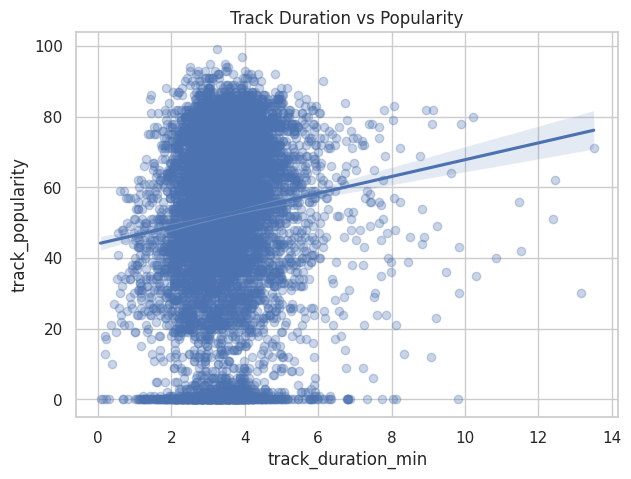

In [ ]:
# Duration vs Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='track_duration_min',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Track Duration vs Popularity")
plt.show()

While the regression line displays a slight positive correlation, interpreting this chart requires looking at the data distribution. The scatter plot reveals a massive density cluster between 2.5 and 4.5 minutes. The vast majority of highly popular tracks (scoring 80+) fall strictly within this "radio-friendly" time frame. The upward trend of the regression line is likely a statistical artifact, skewed heavily by a high volume of very short tracks (under 2 minutes) with near-zero popularity dragging the left side down. Ultimately, standard-length songs dominate the charts, while excessively long tracks rarely achieve peak popularity.

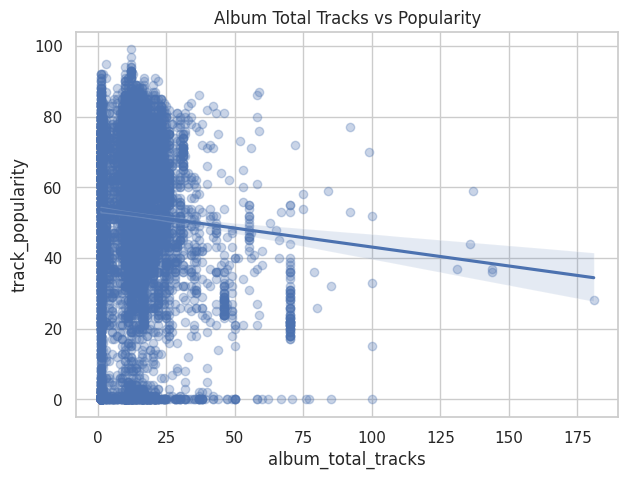

In [ ]:
# Album Total Tracks vs Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='album_total_tracks',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Album Total Tracks vs Popularity")
plt.show()

The regression analysis indicates a notable negative correlation between the total number of tracks in an album and the popularity of individual tracks. Data density is highest for albums with 1 to 25 tracks, where the majority of high-ranking hits (Popularity > 80) are located. As albums grow excessively large (exceeding 50–100 tracks), the average popularity per track tends to decline. This suggests that concise, focused albums generally perform better on streaming platforms compared to long compilations or box sets, which likely contain more niche or filler content.

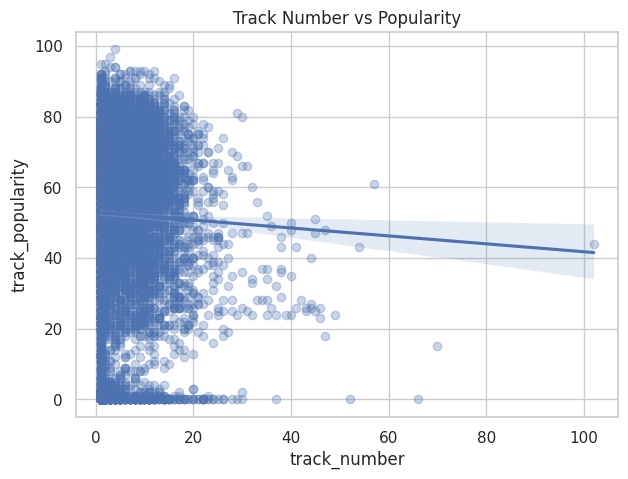

In [ ]:
# Track Number vs Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='track_number',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Track Number vs Popularity")
plt.show()

The regression plot reveals a slight negative correlation between the track's position in an album (track_number) and its popularity. Tracks positioned at the beginning of an album (typically tracks 1-10) exhibit a higher concentration of peak popularity scores. As the track number increases, the average popularity tends to decrease, supporting the theory that opening tracks generally receive more engagement. However, the high dispersion of data points suggests that while track positioning is a factor, it is not the sole determinant of a song's success.

/tmp/ipykernel_1020/2052588165.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


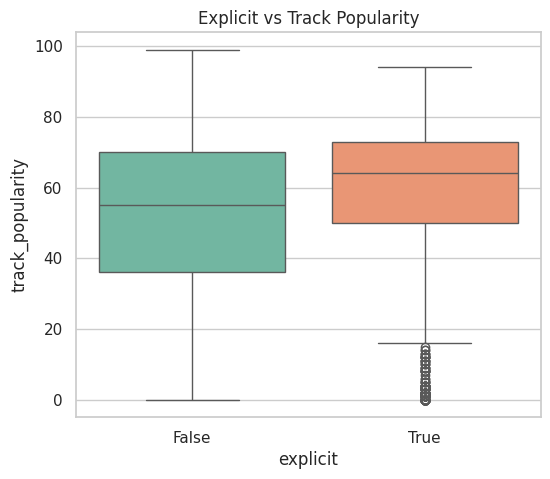

In [ ]:
# Explicit vs Popularity

plt.figure(figsize=(6,5))

sns.boxplot(
    x='explicit',
    y='track_popularity',
    data=df,
    palette='Set2'
)

plt.title("Explicit vs Track Popularity")

plt.show()

Songs with explicit content tend to have slightly higher median popularity than non-explicit songs. However, both groups overlap considerably, suggesting that explicitness alone does not determine success.

/tmp/ipykernel_1020/548883901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


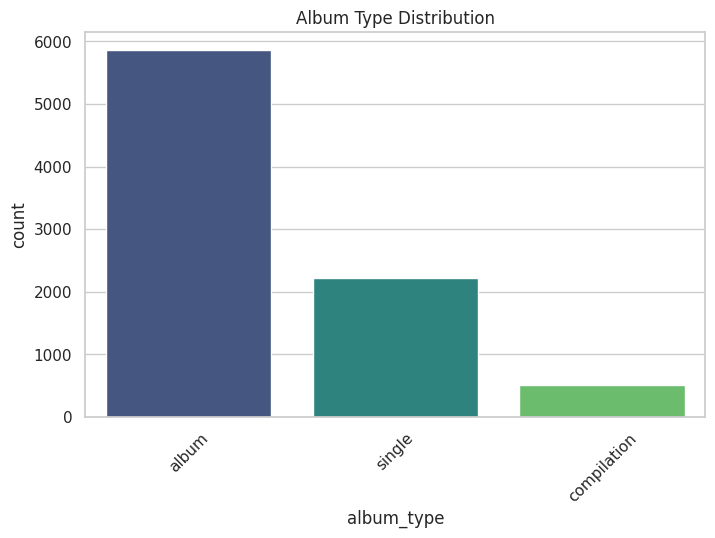

In [ ]:
# Album Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='album_type',
    data=df,
    order=df['album_type'].value_counts().index,
    palette='viridis'
)

plt.title("Album Type Distribution")

plt.xticks(rotation=45)

plt.show()


The chart shows that the majority of tracks in this study come from full-length albums rather than individual releases or collections.

/tmp/ipykernel_1020/563399129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


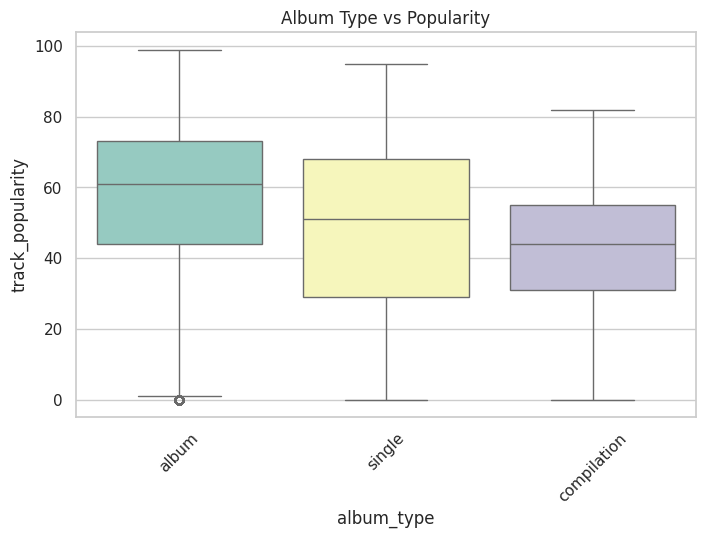

In [ ]:
# Album Type vs Popularity

plt.figure(figsize=(8,5))

sns.boxplot(
    x='album_type',
    y='track_popularity',
    data=df,
    palette='Set3'
)

plt.title("Album Type vs Popularity")

plt.xticks(rotation=45)

plt.show()

Tracks released as part of full albums tend to achieve the highest popularity, while compilation releases perform the weakest. Singles show the greatest variability, suggesting they can either become major hits or receive limited attention.

In [ ]:
# Clean genres
df['artist_genres'] = df['artist_genres'].fillna('Unknown')


/tmp/ipykernel_1020/1829810895.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


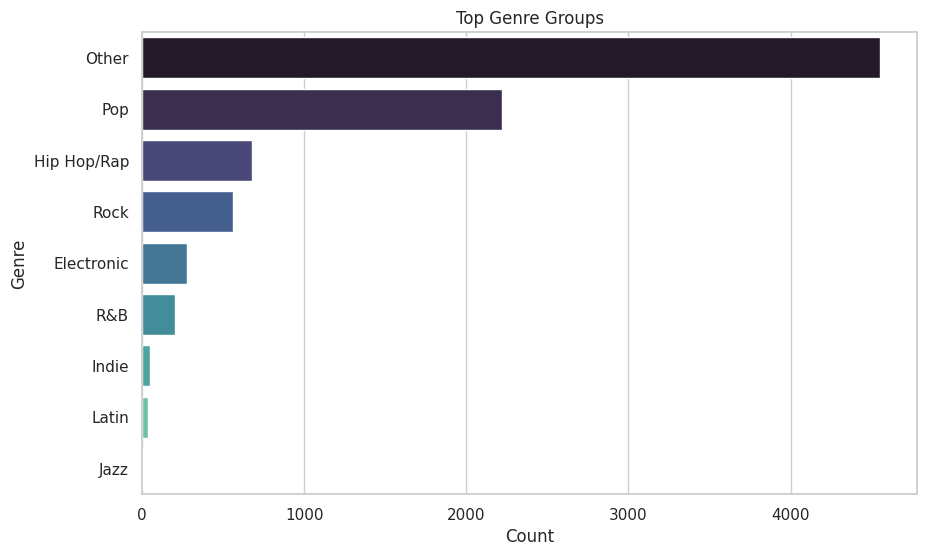

In [ ]:
# Extract all genres

genre_list = []

for genres in df['artist_genres']:

    split_genres = str(genres).split(',')

    split_genres = [
        g.strip().lower()
        for g in split_genres
    ]

    genre_list.extend(split_genres)

# Group similar genres

def simplify_genre(genre):

    if 'pop' in genre:
        return 'Pop'

    elif 'rock' in genre:
        return 'Rock'

    elif 'rap' in genre or 'hip hop' in genre or 'trap' in genre:
        return 'Hip Hop/Rap'

    elif 'electronic' in genre or 'edm' in genre or 'house' in genre:
        return 'Electronic'

    elif 'indie' in genre:
        return 'Indie'

    elif 'r&b' in genre or 'soul' in genre:
        return 'R&B'

    elif 'latin' in genre:
        return 'Latin'

    elif 'jazz' in genre:
        return 'Jazz'

    else:
        return 'Other'

# Create genre_group column

df['genre_group'] = df['artist_genres'].apply(
    lambda x: simplify_genre(str(x))
)

# Top Genre Groups

top_genres = df['genre_group'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='mako'
)

plt.title("Top Genre Groups")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

This bar chart shows the distribution of songs across different genre groups within the dataset. The "Other" category is the most frequent, suggesting a high variety of sub-genres not captured by the main classification logic. Among the defined groups, Pop is the most prevalent genre. When compared to the previous popularity analysis, an interesting contrast emerges: Indie tracks are few in number but hold the highest average popularity, whereas Pop tracks are abundant but maintain only moderate average popularity. This indicates that while the dataset is Pop-heavy, the Indie selections are highly curated or trend-heavy.

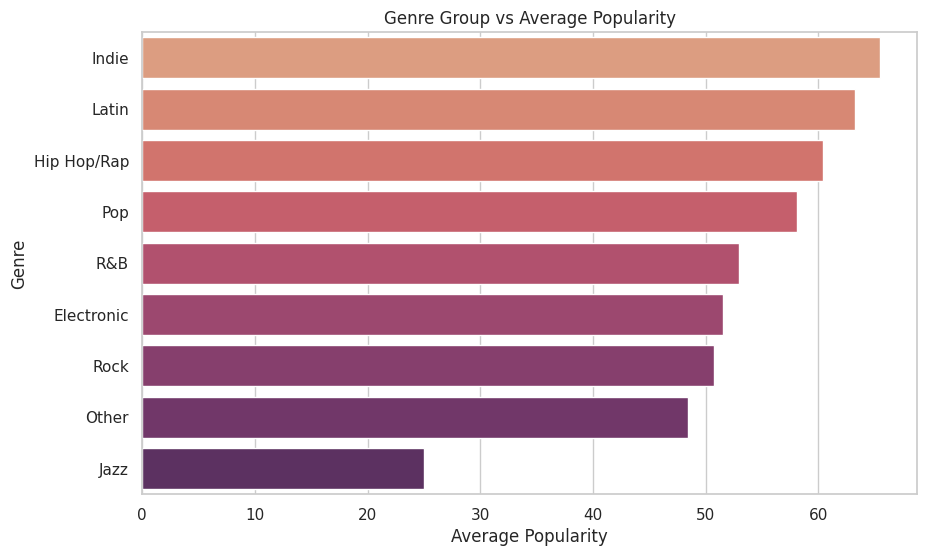

In [ ]:
# Genre vs Average Popularity

genre_popularity = (
    df.groupby('genre_group')['track_popularity']
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    hue=genre_popularity.index,
    legend=False,
    palette='flare'
)

plt.title("Genre Group vs Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()

The bar chart illustrates the average popularity score across various music genre groups. Indie and Latin emerge as the most popular genres, both scoring above 60 on average, closely followed by Hip Hop/Rap. Interestingly, mainstream genres such as Pop, R&B, Electronic, and Rock form a mid-tier cluster with average popularity ranging from 50 to 58. Conversely, Jazz has the lowest average popularity by a significant margin (scoring approximately 25), indicating a more niche listener base within this Spotify dataset.

In [ ]:
# TIME ANALYSIS

In [ ]:
# Convert date

df['album_release_date'] = pd.to_datetime(
    df['album_release_date'],
    errors='coerce'
)

# Extract year

df['release_year'] = df['album_release_date'].dt.year

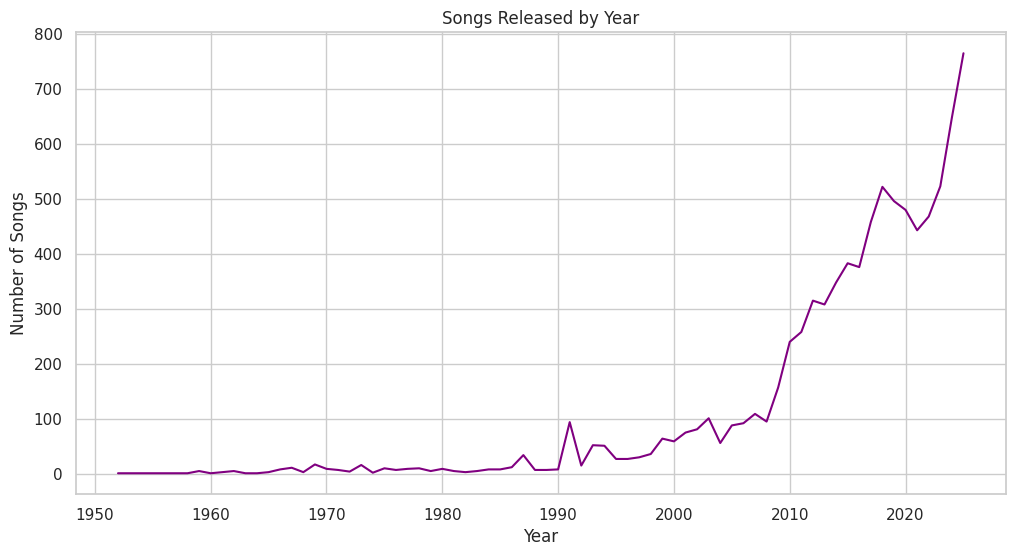

In [ ]:
# Songs Released by Year

plt.figure(figsize=(12,6))

df['release_year'].value_counts() \
    .sort_index() \
    .plot(color='purple')

plt.title("Songs Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Songs")

plt.show()

The line chart of songs released by year shows a strong upward trend in the number of songs over time, especially after 2010. Before 1990, only a relatively small number of songs appear in the dataset each year. From the 2000s onward, the number of releases increases rapidly, reflecting the growth of digital music production and streaming platforms. The highest number of songs is observed in recent years, indicating that the dataset is heavily concentrated on modern music releases.

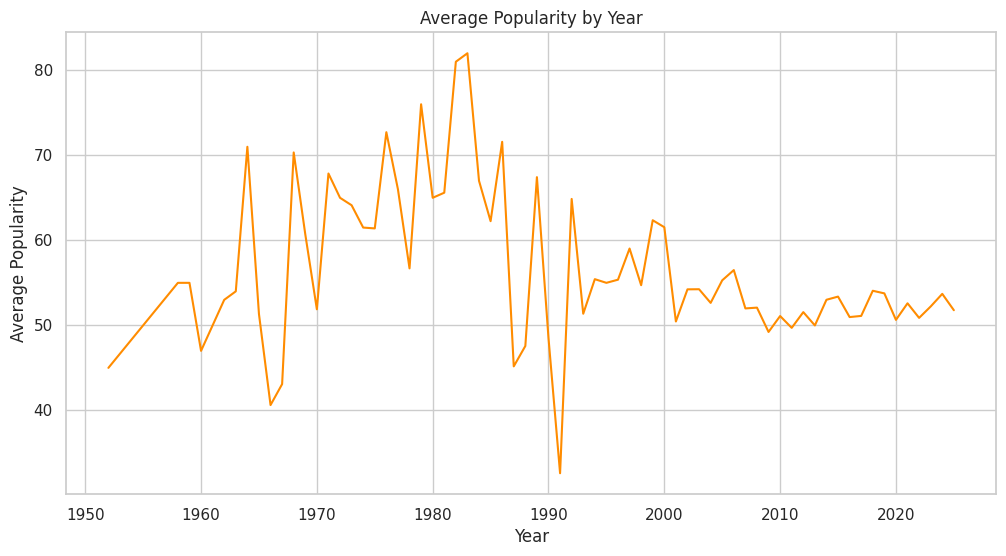

In [ ]:
# Popularity by Year

year_popularity = (
    df.groupby('release_year')['track_popularity']
    .mean()
)

plt.figure(figsize=(12,6))

year_popularity.plot(color='darkorange')

plt.title("Average Popularity by Year")
plt.xlabel("Year")
plt.ylabel("Average Popularity")

plt.show()

The line chart of average popularity by year shows that track popularity fluctuates considerably across different time periods rather than following a consistent upward or downward trend. The highest average popularity levels appear between the 1970s and mid-1980s, with a peak above 80 in the early 1980s. In contrast, several years around the late 1980s and early 1990s experience sharp declines, possibly due to fewer songs or lower popularity tracks in the dataset. From around 2000 onward, the average popularity becomes more stable, remaining mostly between 50 and 55.

***PREPROCESSING***



